# Site CF Generation, BA Weighting, And Validation

This notebook shows how renewable site weather becomes BA-level wind and solar capacity factors and validates the modeled generation against EIA-930 actuals, using MISO as the worked example.

The reviewer route uses the EIA-860 2022 renewable fleet, downloads 2023 site weather from a local HSDS service, runs the no-loss reV configurations, nameplate-weights the site profiles to MISO, and compares modeled renewable generation with 2023 EIA-930 actuals.

The HSDS download uses the same local endpoint, no-key configuration, and `nrel-pds-hsds` bucket as the other HSDS data-flow notebooks. Notebook-created H5 files, CSVs, and figures are scratch outputs under `notebook_outputs/`.


## Imports And Package Setup

Load the libraries used by the HSDS download, reV generation, capacity-factor weighting, and renewable-generation validation.


In [1]:
import json
from pathlib import Path

import h5py
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from reV.SAM.generation import PvWattsv8, WindPower
from rex import Resource

DATA_ROOT = Path("../../data")
MANIFEST_ROOT = Path("../../manifests")
OUTPUT_DIR = Path("../../notebook_outputs/data_flow/site_cf_generation_ba_weighting_validation")

if not DATA_ROOT.is_dir() or not MANIFEST_ROOT.is_dir():
    raise FileNotFoundError(
        "Expected to find the packaged data and manifest folders. "
        "Open this notebook from inside notebooks/data_flow."
    )

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


C:\Users\charl\miniconda3\envs\wxdata\lib\site-packages\reV\SAM\version_checker.py:10: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution


## Step 1: Load Regridded Renewable Site Points

`eia860_regridding_methodology.ipynb` shows how EIA-860 generator rows are filtered, aggregated to renewable site coordinates, and matched to HSDS grid points for each weather source. That process produces files such as `{BA_CODE}_{source}.csv` (for example, `MISO_bchrrr.csv` and `MISO_nsrdb.csv`).

The two files loaded here are `data/eia860/2022_regridded_points/MISO_bchrrr.csv` for wind and `data/eia860/2022_regridded_points/MISO_nsrdb.csv` for solar. Each row gives one renewable site, its selected HSDS `gid`, and the nameplate MW used for capacity weighting.

This validation notebook uses the EIA-860 2022 operable fleet with 2023 weather and EIA-930 actual renewable generation. The production renewable CF files use the EIA-860 2024 operable fleet, so this notebook validates the method rather than the 2024 production fleet directly.

In [2]:
EIA_YEAR = 2022
VALIDATION_YEAR = 2023
BA_CODE = "MISO"  # MISO is the worked example; the method is BA-parameterized.
LOCAL_TIMEZONE = "America/Chicago"
SOURCE_INPUT_ROOT = DATA_ROOT
REGRIDDED_POINT_ROOT = SOURCE_INPUT_ROOT / "eia860" / f"{EIA_YEAR}_regridded_points"

# Keep every technology-specific choice in one place.
TECHNOLOGY_CONFIG = {
    "wind": {
        "source": "bchrrr",
        "input_csv": REGRIDDED_POINT_ROOT / f"{BA_CODE}_bchrrr.csv",
        "gid_column": "bchrrr_gid",
        "nameplate_column": "bchrrr_nameplate",
        "weather_variables": [
            "temperature_2m", "pressure_0m", "windspeed_100m", "winddirection_100m"
        ],
        "resource_path": f"/nrel/wtk/bchrrr/v1.0.0/bchrrr_conus_{VALIDATION_YEAR}.h5",
        "sam_config": "wind_gen_standard_no_losses_2.json",
        "loss_percent": 20.0,
        "loss_label": "20% loss",
        "color": "#2563eb",
    },
    "solar": {
        "source": "nsrdb",
        "input_csv": REGRIDDED_POINT_ROOT / f"{BA_CODE}_nsrdb.csv",
        "gid_column": "nsrdb_gid",
        "nameplate_column": "nsrdb_nameplate",
        "weather_variables": [
            "air_temperature", "wind_speed", "dhi", "dni", "ghi"
        ],
        "resource_path": f"/nrel/nsrdb/GOES/aggregated/v4.0.0/nsrdb_{VALIDATION_YEAR}.h5",
        "sam_config": "i_pvwattsv8_single_axis_backtracking_no_losses.json",
        "loss_percent": 14.075660705566406,
        "loss_label": "14.1% loss",
        "color": "#f97316",
    },
}

site_points_by_technology = {}
site_summary_rows = []

for technology, config in TECHNOLOGY_CONFIG.items():
    # Summarize the regridded site CSV before downloading weather.
    # This confirms how many sites, HSDS grid points, and MW enter the total-MISO CF workflow.
    site_points = pd.read_csv(config["input_csv"]).dropna(
        subset=[config["gid_column"]]
    ).reset_index(drop=True)
    site_points_by_technology[technology] = site_points
    site_summary_rows.append({
        "technology": technology,
        "weather_source": config["source"],
        "site_rows": len(site_points),
        "unique_hsds_gids": int(site_points[config["gid_column"]].nunique()),
        "regridded_nameplate_mw": float(site_points[config["nameplate_column"]].sum()),
    })

display(pd.DataFrame(site_summary_rows))

,technology,weather_source,site_rows,unique_hsds_gids,regridded_nameplate_mw
0,wind,bchrrr,305,305,29845.3
1,solar,nsrdb,539,539,4548.7


## Step 2: Download 2023 Site Weather From HSDS

Before running this step, start the local HSDS service at `http://localhost:5101` with access to the `nrel-pds-hsds` bucket. The download reads the selected wind and solar grid points, keeps top-of-hour timestamps, and writes scratch site-weather H5 files.


### Download Selected Site Weather

Read the selected site grid points for each weather source and write one scratch site-weather H5 file per renewable technology.


In [3]:
HSDS_ENDPOINT = "http://localhost:5101"
HSDS_API_KEY = None
HSDS_BUCKET = "nrel-pds-hsds"
site_weather_h5_by_technology = {}
WEATHER_H5_DIR = OUTPUT_DIR / "site_weather_h5"
WEATHER_H5_DIR.mkdir(parents=True, exist_ok=True)

for technology, config in TECHNOLOGY_CONFIG.items():
    source = config["source"]
    site_points = site_points_by_technology[technology]

    gids = site_points[config["gid_column"]].to_numpy(dtype=int)
    nameplate_mw = site_points[config["nameplate_column"]].to_numpy(dtype=float)

    output_h5 = (
        WEATHER_H5_DIR
        / f"{BA_CODE}_{technology}_{source}_{VALIDATION_YEAR}.h5"
    )

    # 1. Open this weather source's HSDS resource.
    with Resource(
        config["resource_path"],
        hsds=True,
        hsds_kwargs={
            "endpoint": HSDS_ENDPOINT,
            "api_key": HSDS_API_KEY,
            "bucket": HSDS_BUCKET,
        },
    ) as resource:
        # 2. Keep top-of-hour timestamps for every source. NSRDB is sub-hourly; BC-HRRR is already hourly.
        time_index = pd.to_datetime(resource.time_index, utc=True)
        time_positions = np.flatnonzero(time_index.minute == 0)
        selected_times = time_index[time_positions]

        # 3. Build this weather source's site-weather H5 staging file.
        with h5py.File(output_h5, "w") as weather:
            weather.create_dataset(
                "time_utc",
                data=selected_times.strftime(
                    "%Y-%m-%dT%H:%M:%SZ"
                ).tolist(),
                dtype=h5py.string_dtype("utf-8"),
            )
            weather.create_dataset("gids", data=gids, dtype="i8")
            weather.create_dataset(
                "nameplate_mw", data=nameplate_mw, dtype="f8"
            )

            # 4. Save each weather variable as a two-dimensional array: time x site.
            for variable in config["weather_variables"]:
                values = np.asarray(
                    resource[variable, :, gids],
                    dtype=np.float32,
                )[time_positions]

                weather.create_dataset(
                    variable, data=values, dtype="f4"
                )

    site_weather_h5_by_technology[technology] = output_h5
    print(f"Wrote HSDS site weather: {output_h5.relative_to(Path('../..'))}")

Wrote HSDS site weather: notebook_outputs\data_flow\site_cf_generation_ba_weighting_validation\site_weather_h5\MISO_wind_bchrrr_2023.h5
Wrote HSDS site weather: notebook_outputs\data_flow\site_cf_generation_ba_weighting_validation\site_weather_h5\MISO_solar_nsrdb_2023.h5


## Step 3: Convert Site Weather To Site-Level CF With reV

Run the packaged no-scalar-loss SAM configuration for every wind and solar site. Scalar losses are applied later only as validation sensitivities; they are not included in the reference capacity factors. The PVWatts input matches the production `wxdata` path and uses irradiance, air temperature, and wind speed; NSRDB surface pressure is not passed to the PV model.

The resulting H5 files retain the UTC timestamps, HSDS grid IDs, nameplate weights, and one hourly capacity-factor column per site.


In [4]:
SITE_CF_DIR = OUTPUT_DIR / "site_cf_h5"
SITE_CF_DIR.mkdir(parents=True, exist_ok=True)

site_cf_h5_by_technology = {}


### Generate Site-Level Capacity Factors

Read each site-weather H5, execute reV for every site, and write the resulting site-level capacity-factor matrix to a scratch H5.


In [5]:
for technology, config in TECHNOLOGY_CONFIG.items():
    source = config["source"]
    site_points = site_points_by_technology[technology]
    weather_h5 = site_weather_h5_by_technology[technology]
    sam_file = (
        SOURCE_INPUT_ROOT
        / "sam_configs"
        / config["sam_config"]
    )
    site_cf_h5 = (
        SITE_CF_DIR
        / f"{BA_CODE}_{technology}_{source}_{VALIDATION_YEAR}.h5"
    )
    cf_dataset = Path(config["sam_config"]).stem

    # 1. Load the technology-specific no-loss SAM configuration.
    with sam_file.open("r", encoding="utf-8") as handle:
        sam_inputs = json.load(handle)

    # 2. Read the staged validation-year weather and require a complete non-leap year.
    with h5py.File(weather_h5, "r") as weather:
        weather_time = pd.to_datetime(
            weather["time_utc"].asstr()[:], utc=True
        )
        if len(weather_time) != 8760:
            raise AssertionError(
                f"Expected 8,760 hourly {technology} rows for {VALIDATION_YEAR}."
            )
        gids = weather["gids"][:]
        nameplate_mw = weather["nameplate_mw"][:]
        site_cf_profiles = []

        # 3. Run the appropriate reV model once for each site column.
        for site_index in range(len(gids)):
            site_row = site_points.iloc[site_index]
            site_meta = pd.Series({
                "latitude": site_row[f"{source}_lat"],
                "longitude": site_row[f"{source}_lon"],
                "elevation": site_row[f"{source}_elevation"],
                "timezone": site_row[f"{source}_timezone"],
            })
            if technology == "wind":
                site_weather = pd.DataFrame({
                    "temperature": weather["temperature_2m"][:, site_index],
                    "pressure": weather["pressure_0m"][:, site_index] / 101325.0,
                    "windspeed": weather["windspeed_100m"][:, site_index],
                    "winddirection": weather["winddirection_100m"][:, site_index],
                }, index=weather_time)
                model = WindPower(
                    resource=site_weather,
                    meta=site_meta,
                    sam_sys_inputs=sam_inputs,
                    output_request=["cf_profile"],
                )
            else:
                site_weather = pd.DataFrame({
                    "dni": weather["dni"][:, site_index],
                    "dhi": weather["dhi"][:, site_index],
                    "ghi": weather["ghi"][:, site_index],
                    "air_temperature": weather["air_temperature"][:, site_index],
                    "wind_speed": weather["wind_speed"][:, site_index],
                }, index=weather_time)
                model = PvWattsv8(
                    resource=site_weather,
                    meta=site_meta,
                    sam_sys_inputs=sam_inputs,
                    output_request=["cf_profile"],
                )

            model.run()
            site_cf_profiles.append(
                np.asarray(model.outputs["cf_profile"], dtype=np.float32)
            )

    # 4. Combine the site profiles into one time-by-site matrix.
    cf_matrix = np.column_stack(site_cf_profiles)
    if cf_matrix.shape[0] != len(weather_time):
        raise AssertionError("reV output rows do not match the retained hourly timestamps.")

    # 5. Write the site-level CF matrix with its timestamps and weights.
    with h5py.File(site_cf_h5, "w") as site_cf:
        site_cf.attrs["kind"] = "renewable_site_cf"
        site_cf.attrs["technology"] = technology
        site_cf.attrs["sam_config"] = sam_file.name
        site_cf.create_dataset(
            "time_utc",
            data=weather_time.strftime("%Y-%m-%dT%H:%M:%SZ").tolist(),
            dtype=h5py.string_dtype("utf-8"),
        )
        site_cf.create_dataset("gids", data=gids, dtype="i8")
        site_cf.create_dataset("nameplate_mw", data=nameplate_mw, dtype="f8")
        site_cf.create_dataset(cf_dataset, data=cf_matrix, dtype="f4")

    site_cf_h5_by_technology[technology] = site_cf_h5
    print(f"Wrote reV site CF: {site_cf_h5.relative_to(Path('../..'))}")


Wrote reV site CF: notebook_outputs\data_flow\site_cf_generation_ba_weighting_validation\site_cf_h5\MISO_wind_bchrrr_2023.h5
Wrote reV site CF: notebook_outputs\data_flow\site_cf_generation_ba_weighting_validation\site_cf_h5\MISO_solar_nsrdb_2023.h5


## Step 4: Nameplate-Weight Site CF Into BA CF

For each hour, calculate the MISO-level capacity factor from the generated site-CF matrix:

BA_CF_t = sum(site_CF_i,t times nameplate_MW_i) / sum(nameplate_MW_i)

The weighted tables are retained in memory for the EIA-930 validation below and also written to scratch CSVs.


In [6]:
WEIGHTED_CF_DIR = OUTPUT_DIR / "weighted_ba_cf"
WEIGHTED_CF_DIR.mkdir(parents=True, exist_ok=True)

weighted_cf_summary_rows = []
weighted_cf_by_technology = {}

for technology, config in TECHNOLOGY_CONFIG.items():
    source = config["source"]
    file_stem = f"{BA_CODE}_{technology}_{source}_{VALIDATION_YEAR}"
    site_cf_h5 = site_cf_h5_by_technology[technology]
    cf_dataset = Path(config["sam_config"]).stem
    weighted_cf_csv = WEIGHTED_CF_DIR / f"{file_stem}_weighted_cf.csv"

    # 1. Load the site CF matrix and its aligned nameplate weights.
    with h5py.File(site_cf_h5, "r") as site_cf:
        time_utc = pd.to_datetime(site_cf["time_utc"].asstr()[:], utc=True)
        site_cf_matrix = site_cf[cf_dataset][:]
        nameplate_mw = site_cf["nameplate_mw"][:]

    # 2. Nameplate-weight the site columns into one BA-level CF series.
    ba_cf = np.average(site_cf_matrix, axis=1, weights=nameplate_mw)
    ba_cf_table = pd.DataFrame({
        "time_utc": time_utc,
        f"{technology}_cf": ba_cf,
    })

    # 3. Retain and save the weighted series, then record its summary statistics.
    weighted_cf_by_technology[technology] = ba_cf_table
    ba_cf_table.to_csv(
        weighted_cf_csv, index=False, date_format="%Y-%m-%dT%H:%M:%SZ"
    )
    weighted_cf_summary_rows.append({
        "technology": technology,
        "weather_source": source,
        "hours_written": len(ba_cf_table),
        "site_count": site_cf_matrix.shape[1],
        "nameplate_mw": float(nameplate_mw.sum()),
        "mean_ba_cf": float(ba_cf.mean()),
        "output_csv": weighted_cf_csv.relative_to(Path("../..")).as_posix(),
    })

display(pd.DataFrame(weighted_cf_summary_rows))


,technology,weather_source,hours_written,site_count,nameplate_mw,mean_ba_cf,output_csv
0,wind,bchrrr,8760,305,29845.3,0.415726,notebook_outputs/data_flow/site_cf_generation_...
1,solar,nsrdb,8760,539,4548.7,0.193894,notebook_outputs/data_flow/site_cf_generation_...


## Step 5: Validate Modeled Renewable Generation Against EIA-930 Actuals

Convert the Step 4 capacity factors to modeled MW using the EIA-860 2022 installed wind and solar capacity, then compare them with 2023 EIA-930 actual generation. The no-loss series is the direct reV result; the scalar-loss series is included only as a validation sensitivity and is not written back to the capacity-factor files.


In [7]:
# 1. Load the single installed-capacity record for the validation BA.
capacity_manifest = pd.read_csv(
    MANIFEST_ROOT / f"eia860_{EIA_YEAR}_operable_capacity_manifest.csv"
)
capacity_rows = capacity_manifest[capacity_manifest["BA"].eq(BA_CODE)]
if len(capacity_rows) != 1:
    raise AssertionError(f"Expected exactly one {BA_CODE} capacity row.")
capacity_row = capacity_rows.iloc[0]

validation_by_technology = {}
metric_rows = []

for technology, config in TECHNOLOGY_CONFIG.items():
    cf_column = f"{technology}_cf"
    actual_column = f"{technology}_actual_mw"
    actual_path = (
        SOURCE_INPUT_ROOT
        / "renewable_actuals"
        / f"{BA_CODE}_{technology}_{VALIDATION_YEAR}.csv"
    )

    # 2. Load modeled CF and actual generation.
    modeled_cf = weighted_cf_by_technology[technology]
    actual = pd.read_csv(actual_path, usecols=["time_utc", actual_column])
    actual["time_utc"] = pd.to_datetime(actual["time_utc"], utc=True)

    # 3. Align the modeled and observed series to the validation year.
    comparison = modeled_cf.merge(
        actual, on="time_utc", how="inner", validate="one_to_one"
    )
    comparison = comparison[
        comparison["time_utc"].dt.year.eq(VALIDATION_YEAR)
    ].reset_index(drop=True)
    if len(comparison) != 8760:
        raise AssertionError(
            f"Expected 8,760 aligned {technology} validation hours."
        )
    if comparison[[cf_column, actual_column]].isna().any().any():
        raise AssertionError(f"Aligned {technology} validation contains missing values.")

    # 4. Convert CF to MW and apply the scalar-loss sensitivity.
    installed_mw = float(
        capacity_row[f"Installed {technology.title()} (MW)"]
    )
    loss_percent = config["loss_percent"]
    comparison["modeled_mw_0pct_loss"] = comparison[cf_column] * installed_mw
    comparison["modeled_mw_scalar_loss"] = (
        comparison["modeled_mw_0pct_loss"] * (1 - loss_percent / 100)
    )
    validation_by_technology[technology] = comparison

    # 5. Calculate error metrics for the no-loss and scalar-loss cases.
    cases = [
        ("0% loss", "modeled_mw_0pct_loss", 0.0),
        (config["loss_label"], "modeled_mw_scalar_loss", loss_percent),
    ]
    for case_label, modeled_column, case_loss_percent in cases:
        error = comparison[modeled_column] - comparison[actual_column]
        metric_rows.append({
            "case": f"{technology.title()}: {case_label}",
            "loss_percent": case_loss_percent,
            "mae_mw": float(error.abs().mean()),
            "rmse_mw": float(np.sqrt(np.mean(error**2))),
            "bias_mw": float(error.mean()),
            "n_obs": int(error.notna().sum()),
        })

# 6. Save the technology-by-loss metric rows.
validation_metrics = pd.DataFrame(metric_rows)
metrics_path = (
    OUTPUT_DIR
    / f"{BA_CODE.lower()}_{VALIDATION_YEAR}_renewable_loss_sensitivity_metrics.csv"
)
validation_metrics.to_csv(metrics_path, index=False)
display(validation_metrics.round(2))


,case,loss_percent,mae_mw,rmse_mw,bias_mw,n_obs
0,Wind: 0% loss,0.00,2421.16,3107.22,1937.03,8760
1,Wind: 20% loss,20.00,1247.76,1599.43,-544.46,8760
2,Solar: 0% loss,0.00,245.33,411.95,157.34,8760
3,Solar: 14.1% loss,14.08,181.97,310.04,33.20,8760


### Plot The January 2023 Validation Window

Plot one readable month in local Central time, showing EIA-930 actual generation, the direct no-loss modeled series, and the scalar-loss sensitivity for wind and solar.


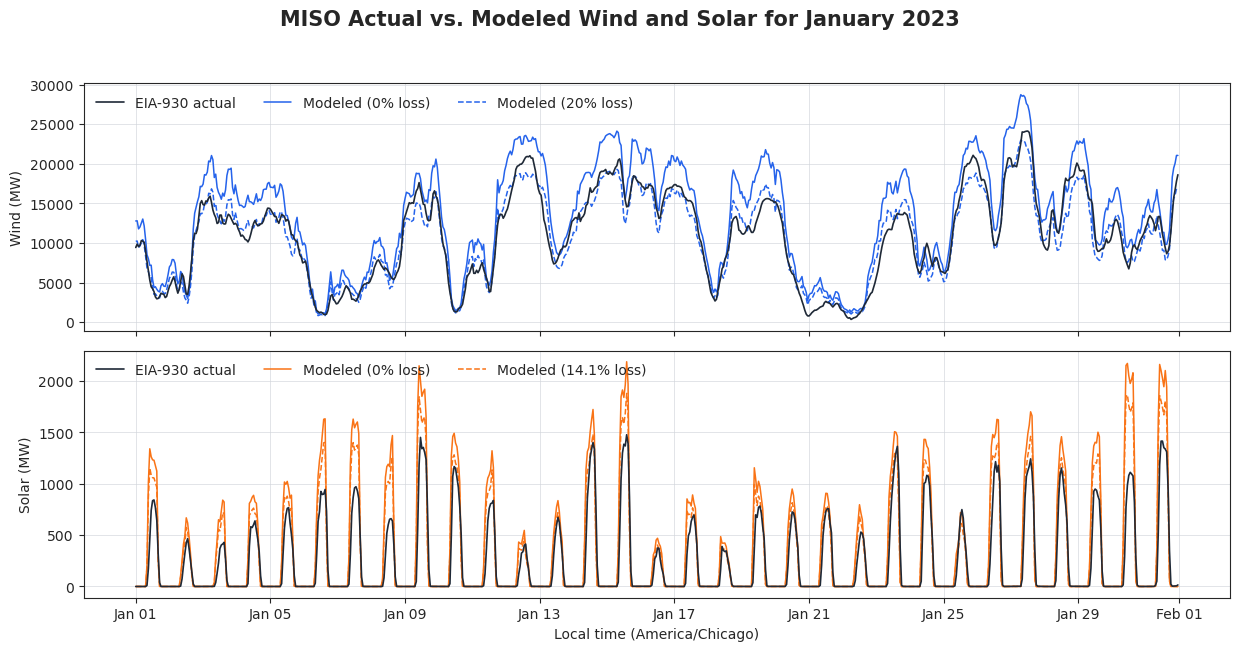

In [8]:
ACTUAL_COLOR = "#1f2937"

fig, axes = plt.subplots(
    2, 1, figsize=(12.5, 6.6), sharex=True
)

# 1. Build and plot each technology's complete January window.
for axis, (technology, config) in zip(
    axes, TECHNOLOGY_CONFIG.items(), strict=True
):
    comparison = validation_by_technology[technology]
    local = comparison.assign(
        time_local=comparison["time_utc"].dt.tz_convert(LOCAL_TIMEZONE)
    )
    plot_data = local[
        local["time_local"].dt.year.eq(VALIDATION_YEAR)
        & local["time_local"].dt.month.eq(1)
    ]
    actual_column = f"{technology}_actual_mw"
    axis.plot(
        plot_data["time_local"],
        plot_data[actual_column],
        color=ACTUAL_COLOR,
        linewidth=1.2,
        label="EIA-930 actual",
        zorder=3,
    )
    axis.plot(
        plot_data["time_local"],
        plot_data["modeled_mw_0pct_loss"],
        color=config["color"],
        linewidth=1.1,
        label="Modeled (0% loss)",
    )
    axis.plot(
        plot_data["time_local"],
        plot_data["modeled_mw_scalar_loss"],
        color=config["color"],
        linewidth=1.1,
        linestyle="--",
        label=f"Modeled ({config['loss_label']})",
    )
    axis.set_ylabel(f"{technology.title()} (MW)")
    axis.grid(True, color="#d1d5db", linewidth=0.7, alpha=0.65)
    axis.legend(loc="upper left", frameon=False, ncol=3)

# 2. Apply the shared time-axis formatting and save the figure.
axes[-1].set_xlabel(f"Local time ({LOCAL_TIMEZONE})")
axes[-1].xaxis.set_major_locator(
    mdates.DayLocator(bymonthday=range(1, 32, 4), tz=LOCAL_TIMEZONE)
)
axes[-1].xaxis.set_major_formatter(
    mdates.DateFormatter("%b %d", tz=LOCAL_TIMEZONE)
)
fig.suptitle(
    f"{BA_CODE} Actual vs. Modeled Wind and Solar for January {VALIDATION_YEAR}",
    fontsize=15,
    fontweight="bold",
)
fig.tight_layout(rect=(0, 0, 1, 0.95))
figure_path = (
    OUTPUT_DIR
    / f"{BA_CODE.lower()}_{VALIDATION_YEAR}0101_{VALIDATION_YEAR}0131_renewable_loss_sensitivity.png"
)
fig.savefig(figure_path, dpi=200, bbox_inches="tight")
plt.show()


## Appendix A: State-Level Aggregation Demonstration

This compact extension reuses the EIA-860 2022 MISO sites and the 2023 site-CF matrices generated above. It selects sites whose regridded state is Iowa and applies the same nameplate-weighted average used for total MISO. Because the worked inputs contain only MISO sites, the result is the **MISO-contributed Iowa subset**, not a complete statewide CF product.

Complete production state CF accumulates the weighted numerator and capacity across every contributing source BA before division:

\[
CF_{k,s,t}=\frac{\sum_b\sum_{i\in(s,b)} C_i CF_{i,t}}{\sum_b\sum_{i\in(s,b)} C_i}.
\]

EIA-930 does not provide state-level renewable-generation actuals, so this appendix demonstrates the geographic aggregation and internal consistency checks; it is not a state-level validation.

In [9]:
STATE_NAME = "Iowa"
iowa_miso_cf = {}
state_summary_rows = []

for technology, config in TECHNOLOGY_CONFIG.items():
    source = config["source"]
    site_points = site_points_by_technology[technology]
    state_column = f"{source}_state"
    site_cf_h5 = site_cf_h5_by_technology[technology]
    cf_dataset = Path(config["sam_config"]).stem

    # 1. Load the site CF profiles, gids, and nameplate weights.
    with h5py.File(site_cf_h5, "r") as site_cf:
        time_utc = pd.to_datetime(
            site_cf["time_utc"].asstr()[:], utc=True
        )
        h5_gids = site_cf["gids"][:].astype(int)
        nameplate_mw = site_cf["nameplate_mw"][:]
        site_cf_matrix = site_cf[cf_dataset][:]

    # 2. Confirm that the H5 columns still match the source site table.
    metadata_gids = site_points[config["gid_column"]].to_numpy(dtype=int)
    metadata_nameplate = site_points[config["nameplate_column"]].to_numpy(dtype=float)
    if not np.array_equal(h5_gids, metadata_gids):
        raise AssertionError(f"{technology} H5 gids do not match the EIA-860 {EIA_YEAR} site order.")
    np.testing.assert_allclose(nameplate_mw, metadata_nameplate, rtol=0, atol=1e-6)

    # 3. Select Iowa sites and nameplate-weight them into a state subset.
    keep_sites = site_points[state_column].eq(STATE_NAME).to_numpy()
    if not keep_sites.any():
        raise AssertionError(f"No {technology} sites found for {STATE_NAME}.")
    weighted_cf = np.average(site_cf_matrix[:, keep_sites], axis=1, weights=nameplate_mw[keep_sites])
    iowa_miso_cf[technology] = pd.Series(weighted_cf, index=time_utc, name=f"{technology}_cf")
    state_summary_rows.append({
        "technology": technology, "hours": len(weighted_cf), "site_count": int(keep_sites.sum()),
        "nameplate_mw": float(nameplate_mw[keep_sites].sum()), "mean_cf": float(weighted_cf.mean()),
    })

# 4. Align the technology series and validate the resulting CF bounds.
if not iowa_miso_cf["wind"].index.equals(iowa_miso_cf["solar"].index):
    raise AssertionError("Iowa wind and solar timestamps are not aligned.")
state_preview = pd.concat(iowa_miso_cf.values(), axis=1).rename_axis("time_utc").reset_index()
if state_preview["time_utc"].duplicated().any():
    raise AssertionError("Iowa timestamps must be unique.")
cf_values = state_preview[["wind_cf", "solar_cf"]]
if not (cf_values.ge(0).all().all() and cf_values.le(1).all().all()):
    raise AssertionError("Iowa CF values must remain within [0, 1].")

print("MISO-contributed Iowa subset (EIA-860 2022 fleet, 2023 weather)")
print(pd.DataFrame(state_summary_rows).round(4).to_string(index=False))
print("\nFirst four weighted hours")
print(state_preview.head(4).round(4).to_string(index=False))


MISO-contributed Iowa subset (EIA-860 2022 fleet, 2023 weather)
technology  hours  site_count  nameplate_mw  mean_cf
      wind   8760         107       12421.3   0.4234
     solar   8760          16         260.4   0.1984

First four weighted hours
                 time_utc  wind_cf  solar_cf
2023-01-01 00:00:00+00:00   0.4680       0.0
2023-01-01 01:00:00+00:00   0.4213       0.0
2023-01-01 02:00:00+00:00   0.3961       0.0
2023-01-01 03:00:00+00:00   0.3470       0.0


## Downstream Use

The BA wind and solar CF files feed net-load workflows after conversion from CF to generation MW. This notebook provides the renewable-only validation; the separate [miso_wind_solar_load_validation.ipynb](../validation/miso_wind_solar_load_validation.ipynb) retains the combined wind, solar, and load view. For downstream BA scenario metrics, see [ba_scenario_metrics_generation.ipynb](ba_scenario_metrics_generation.ipynb).